# **Neural-Sense: Sentiment Classification of Consumer Reviews using RNNs/LSTMs**

# **Install & Import Dependencies**

In [3]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.datasets import imdb

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **Configuration / Hyperparameters**

In [4]:
# ── Global Config ────────────────────────────────────────────
VOCAB_SIZE    = 20000   # top N most frequent words to keep
MAX_LEN       = 256     # pad/truncate all reviews to this length
EMBED_DIM     = 128     # embedding vector dimensionality
LSTM_UNITS_1  = 128     # units in first LSTM layer
LSTM_UNITS_2  = 64      # units in second LSTM layer
DROPOUT_RATE  = 0.4     # dropout probability
BATCH_SIZE    = 128
EPOCHS        = 20      # EarlyStopping will usually stop earlier
LEARNING_RATE = 1e-3

MODEL_SAVE_PATH = "neural_sense_model.h5"
META_SAVE_PATH  = "neural_sense_meta.npz"   # vocab size & max_len for the app

print("Config loaded ✔")
print(f"  Vocab size : {VOCAB_SIZE:,}")
print(f"  Max length : {MAX_LEN}")
print(f"  Embed dim  : {EMBED_DIM}")
print(f"  LSTM units : {LSTM_UNITS_1} → {LSTM_UNITS_2}")

Config loaded ✔
  Vocab size : 20,000
  Max length : 256
  Embed dim  : 128
  LSTM units : 128 → 64


# **Load & Explore the IMDb Dataset**

In [5]:
# Load IMDb — already tokenised into integer indices
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print("=" * 55)
print("IMDb Dataset Summary")
print("=" * 55)
print(f"  Training samples  : {len(X_train):,}")
print(f"  Test samples      : {len(X_test):,}")
print(f"  Label distribution (train) — 0=Neg, 1=Pos")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"    {u} : {c:,}  ({c/len(y_train)*100:.1f}%)")

# Review length statistics
lengths = [len(r) for r in X_train]
print(f"\n  Review length stats (tokens):")
print(f"    Min    : {np.min(lengths)}")
print(f"    Max    : {np.max(lengths):,}")
print(f"    Mean   : {np.mean(lengths):.1f}")
print(f"    Median : {np.median(lengths):.1f}")
print(f"    Std    : {np.std(lengths):.1f}")
print("=" * 55)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
IMDb Dataset Summary
  Training samples  : 25,000
  Test samples      : 25,000
  Label distribution (train) — 0=Neg, 1=Pos
    0 : 12,500  (50.0%)
    1 : 12,500  (50.0%)

  Review length stats (tokens):
    Min    : 11
    Max    : 2,494
    Mean   : 238.7
    Median : 178.0
    Std    : 176.5


# **Exploratory Data Analysis (EDA) Visualisations**

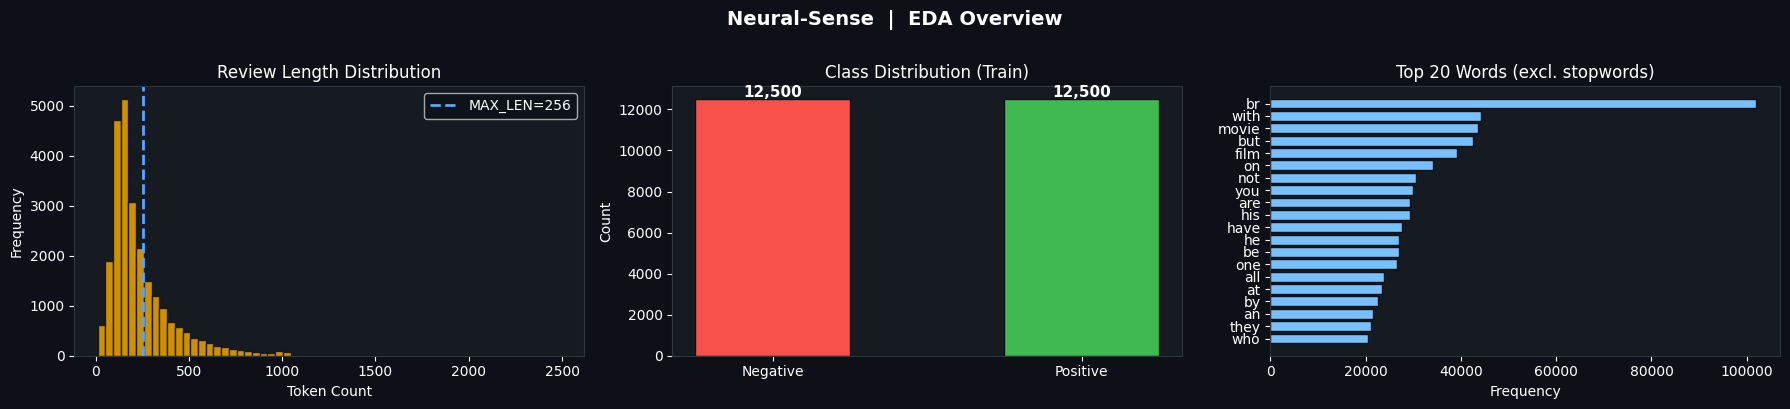

EDA plot saved ✔

── Sample Decoded Review ─────────────────────────────
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it ...
Label: Positive


In [12]:
# Build the word index for decoding later
word_index = imdb.get_word_index()
index_word = {v + 3: k for k, v in word_index.items()}
index_word[0] = "<PAD>"
index_word[1] = "<START>"
index_word[2] = "<UNK>"
index_word[3] = "<UNUSED>"

def decode_review(encoded):
    return " ".join(index_word.get(i, "?") for i in encoded)

# ── Plot 1 : Review length distribution ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.patch.set_facecolor("#0d1117")
for ax in axes:
    ax.set_facecolor("#161b22")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")

# Distribution of lengths
axes[0].hist(lengths, bins=60, color="#f0a500", edgecolor="#0d1117", alpha=0.85)
axes[0].axvline(MAX_LEN, color="#58a6ff", linestyle="--", lw=2, label=f"MAX_LEN={MAX_LEN}")
axes[0].set_title("Review Length Distribution")
axes[0].set_xlabel("Token Count")
axes[0].set_ylabel("Frequency")
axes[0].legend(labelcolor="white", facecolor="#0d1117")

# Class distribution
class_counts = [np.sum(y_train == 0), np.sum(y_train == 1)]
bars = axes[1].bar(["Negative", "Positive"], class_counts,
                   color=["#f85149", "#3fb950"], edgecolor="#0d1117", width=0.5)
for bar, cnt in zip(bars, class_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f"{cnt:,}", ha="center", color="white", fontsize=11, fontweight="bold")
axes[1].set_title("Class Distribution (Train)")
axes[1].set_ylabel("Count")

# Top-20 most frequent words (excluding stop words roughly)
stop_ids = {word_index.get(w, 0) + 3 for w in
            ["the","a","and","of","to","is","in","it","i","this","that","was","as","for"]}
all_words = [w for rev in X_train for w in rev if w not in stop_ids and w > 3]
word_freq  = Counter(all_words).most_common(20)
words_plot, freqs_plot = zip(*word_freq)
word_labels = [index_word.get(w, "?") for w in words_plot]
axes[2].barh(word_labels[::-1], freqs_plot[::-1], color="#79c0ff", edgecolor="#0d1117")
axes[2].set_title("Top 20 Words (excl. stopwords)")
axes[2].set_xlabel("Frequency")

plt.suptitle("Neural-Sense  |  EDA Overview", color="white", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("EDA plot saved ✔")

# Print a decoded sample review
print("\n── Sample Decoded Review ─────────────────────────────")
print(decode_review(X_train[0])[:400], "...")
print(f"Label: {'Positive' if y_train[0] == 1 else 'Negative 😞'}")

# **Text Preprocessing (Padding)**

In [13]:
X_train_pad = pad_sequences(X_train, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test,  maxlen=MAX_LEN, padding="post", truncating="post")

print("After padding:")
print(f"  X_train shape : {X_train_pad.shape}")
print(f"  X_test  shape : {X_test_pad.shape}")
print(f"  dtype         : {X_train_pad.dtype}")

# Save meta so the Streamlit app can reconstruct sequences
np.savez(META_SAVE_PATH, vocab_size=VOCAB_SIZE, max_len=MAX_LEN)
print(f"\nMeta saved → {META_SAVE_PATH}")

After padding:
  X_train shape : (25000, 256)
  X_test  shape : (25000, 256)
  dtype         : int32

Meta saved → neural_sense_meta.npz


# **Build Model A: SimpleRNN (Baseline)**

In [8]:
def build_simple_rnn(vocab_size, embed_dim, max_len):
    model = keras.Sequential([
        layers.Embedding(vocab_size, embed_dim, input_length=max_len, name="embedding"),
        layers.SimpleRNN(64, name="simple_rnn"),
        layers.Dropout(DROPOUT_RATE, name="dropout"),
        layers.Dense(32, activation="relu", name="fc1"),
        layers.Dense(1, activation="sigmoid", name="output")
    ], name="SimpleRNN_Model")
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall")]
    )
    return model

rnn_model = build_simple_rnn(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# **Train SimpleRNN**

In [9]:
rnn_callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

print("Training SimpleRNN baseline …")
t0 = time.time()
rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    validation_split=0.15,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=rnn_callbacks,
    verbose=1
)
rnn_train_time = time.time() - t0
print(f"\nSimpleRNN training done in {rnn_train_time/60:.1f} min")

# Quick eval
rnn_loss, rnn_acc, rnn_prec, rnn_rec = rnn_model.evaluate(X_test_pad, y_test, verbose=0)
rnn_f1 = 2 * rnn_prec * rnn_rec / (rnn_prec + rnn_rec + 1e-8)
print(f"SimpleRNN Test  → Acc: {rnn_acc:.4f} | P: {rnn_prec:.4f} | R: {rnn_rec:.4f} | F1: {rnn_f1:.4f}")

Training SimpleRNN baseline …
Epoch 1/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.5065 - loss: 0.6979 - precision: 0.5069 - recall: 0.5439 - val_accuracy: 0.5000 - val_loss: 0.6953 - val_precision: 0.4868 - val_recall: 0.1880 - learning_rate: 0.0010
Epoch 2/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.5103 - loss: 0.6948 - precision: 0.5119 - recall: 0.4775 - val_accuracy: 0.5005 - val_loss: 0.6941 - val_precision: 0.4913 - val_recall: 0.2581 - learning_rate: 0.0010
Epoch 3/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5193 - loss: 0.6920 - precision: 0.5205 - recall: 0.5137 - val_accuracy: 0.5029 - val_loss: 0.6935 - val_precision: 0.4933 - val_recall: 0.1584 - learning_rate: 0.0010
Epoch 4/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5673 - loss: 0.6645 - precision: 0.5707 - recall: 0.5496 - val_accuracy: 0.5048 - val_loss: 0.7127 - val_precision: 0.4994 - val_recall: 0.2204 - learning_rate: 0.0010
Epoch 5/20
166/167 ━━━━━━━━━━

# **Build Model B: Bidirectional LSTM (Main Model)**

In [10]:
def build_lstm_model(vocab_size, embed_dim, max_len):
    inputs = keras.Input(shape=(max_len,), name="input")

    # Embedding
    x = layers.Embedding(vocab_size, embed_dim, input_length=max_len, name="embedding")(inputs)
    x = layers.SpatialDropout1D(0.2, name="spatial_dropout")(x)

    # Bidirectional LSTM stack
    x = layers.Bidirectional(
            layers.LSTM(LSTM_UNITS_1, return_sequences=True,
                        dropout=0.2, recurrent_dropout=0.1,
                        kernel_regularizer=regularizers.l2(1e-4)),
            name="bidir_lstm_1")(x)
    x = layers.Bidirectional(
            layers.LSTM(LSTM_UNITS_2, return_sequences=False,
                        dropout=0.2, recurrent_dropout=0.1),
            name="bidir_lstm_2")(x)

    # Dense head
    x = layers.Dense(64, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4), name="fc1")(x)
    x = layers.BatchNormalization(name="bn")(x)
    x = layers.Dropout(DROPOUT_RATE, name="dropout")(x)
    x = layers.Dense(32, activation="relu", name="fc2")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = keras.Model(inputs, outputs, name="BiLSTM_NeuralSense")
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall"),
                 keras.metrics.AUC(name="auc")]
    )
    return model

lstm_model = build_lstm_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
lstm_model.summary()
print(f"\nTotal trainable params: {lstm_model.count_params():,}")

Model: "BiLSTM_NeuralSense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 256, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 256, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidir_lstm_1 (Bidirectional)    │ (None, 256, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidir_lstm_2 (Bidirectional)    │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn (BatchNormalization)         │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,998,145 (11.44 MB)

 Trainable params: 2,998,017 (11.44 MB)

 Non-trainable params: 128 (512.00 B)


Total trainable params: 2,998,145


# **Train Bidirectional LSTM**

In [11]:
lstm_callbacks = [
    EarlyStopping(monitor="val_auc", patience=4, mode="max",
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.4, patience=2,
                      min_lr=1e-6, verbose=1),
    ModelCheckpoint(MODEL_SAVE_PATH, monitor="val_auc", mode="max",
                    save_best_only=True, verbose=1)
]

print("Training Bidirectional LSTM …")
t0 = time.time()
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.15,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=lstm_callbacks,
    verbose=1
)
lstm_train_time = time.time() - t0
print(f"\nBiLSTM training done in {lstm_train_time/60:.1f} min")

lstm_loss, lstm_acc, lstm_prec, lstm_rec, lstm_auc = lstm_model.evaluate(
    X_test_pad, y_test, verbose=0)
lstm_f1 = 2 * lstm_prec * lstm_rec / (lstm_prec + lstm_rec + 1e-8)
print(f"BiLSTM   Test  → Acc: {lstm_acc:.4f} | P: {lstm_prec:.4f} | R: {lstm_rec:.4f} | F1: {lstm_f1:.4f} | AUC: {lstm_auc:.4f}")

Training Bidirectional LSTM …
Epoch 1/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6016 - auc: 0.6530 - loss: 0.6733 - precision: 0.6060 - recall: 0.5809
Epoch 1: val_auc improved from None to 0.90140, saving model to neural_sense_model.h5



Epoch 1: finished saving model to neural_sense_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 577s 3s/step - accuracy: 0.6991 - auc: 0.7855 - loss: 0.5813 - precision: 0.6944 - recall: 0.7132 - val_accuracy: 0.7533 - val_auc: 0.9014 - val_loss: 0.5368 - val_precision: 0.6748 - val_recall: 0.9682 - learning_rate: 0.0010
Epoch 2/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8232 - auc: 0.8938 - loss: 0.4319 - precision: 0.8188 - recall: 0.8363
Epoch 2: val_auc did not improve from 0.90140
167/167 ━━━━━━━━━━━━━━━━━━━━ 544s 3s/step - accuracy: 0.8431 - auc: 0.9133 - loss: 0.3954 - precision: 0.8408 - recall: 0.8470 - val_accuracy: 0.7749 - val_auc: 0.8563 - val_loss: 0.5074 - val_precision: 0.7658 - val_recall: 0.7856 - learning_rate: 0.0010
Epoch 3/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8438 - auc: 0.9168 - loss: 0.3873 - precision: 0.8320 - recall: 0.8675
Epoch 3: val_auc improved from 0.90140 to 0.91929, saving model to neural_sense_model.h5



Epoch 3: finished saving model to neural_sense_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 549s 3s/step - accuracy: 0.8768 - auc: 0.9429 - loss: 0.3255 - precision: 0.8709 - recall: 0.8852 - val_accuracy: 0.8536 - val_auc: 0.9193 - val_loss: 0.4081 - val_precision: 0.8728 - val_recall: 0.8244 - learning_rate: 0.0010
Epoch 4/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8950 - auc: 0.9580 - loss: 0.2812 - precision: 0.8890 - recall: 0.9057
Epoch 4: val_auc improved from 0.91929 to 0.92035, saving model to neural_sense_model.h5



Epoch 4: finished saving model to neural_sense_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 553s 3s/step - accuracy: 0.9105 - auc: 0.9671 - loss: 0.2499 - precision: 0.9079 - recall: 0.9141 - val_accuracy: 0.8491 - val_auc: 0.9203 - val_loss: 0.4587 - val_precision: 0.8022 - val_recall: 0.9224 - learning_rate: 0.0010
Epoch 5/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9290 - auc: 0.9777 - loss: 0.2042 - precision: 0.9279 - recall: 0.9322
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0004000000189989805.

Epoch 5: val_auc did not improve from 0.92035
167/167 ━━━━━━━━━━━━━━━━━━━━ 561s 3s/step - accuracy: 0.9376 - auc: 0.9821 - loss: 0.1840 - precision: 0.9381 - recall: 0.9373 - val_accuracy: 0.8413 - val_auc: 0.9117 - val_loss: 0.5635 - val_precision: 0.7875 - val_recall: 0.9305 - learning_rate: 0.0010
Epoch 6/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9464 - auc: 0.9852 - loss: 0.1653 - precision: 0.9411 - recall: 0.9539
Epoch 6: val_auc did not improve fro

# **Visualise Training History (Both Models)**

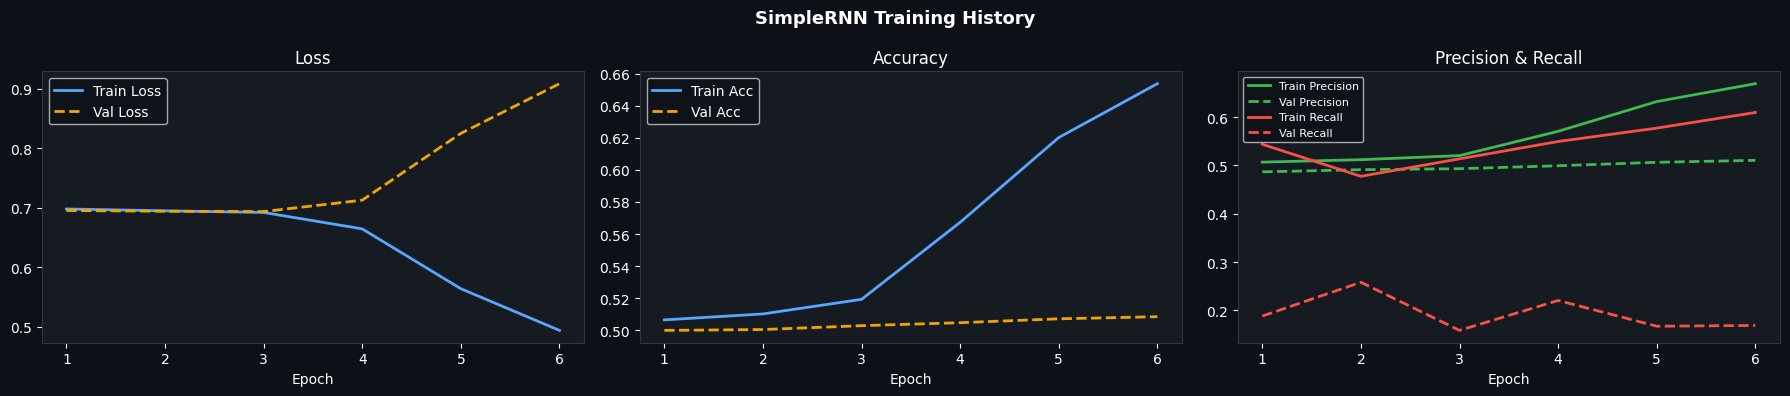

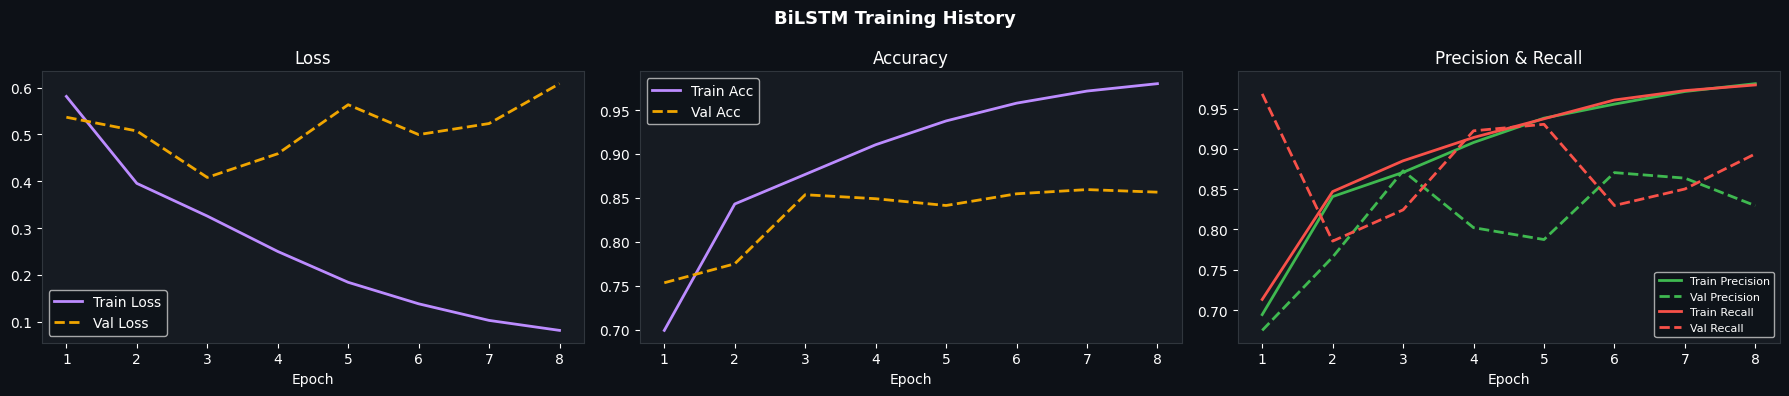

In [14]:
def plot_history(history, title, color):
    epochs_ran = range(1, len(history.history["loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.patch.set_facecolor("#0d1117")
    for ax in axes:
        ax.set_facecolor("#161b22")
        ax.tick_params(colors="white")
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
        ax.title.set_color("white")
        for spine in ax.spines.values():
            spine.set_edgecolor("#30363d")

    # Loss
    axes[0].plot(epochs_ran, history.history["loss"],     color=color,    lw=2, label="Train Loss")
    axes[0].plot(epochs_ran, history.history["val_loss"], color="#f0a500", lw=2, linestyle="--", label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend(labelcolor="white", facecolor="#0d1117")

    # Accuracy
    axes[1].plot(epochs_ran, history.history["accuracy"],     color=color,    lw=2, label="Train Acc")
    axes[1].plot(epochs_ran, history.history["val_accuracy"], color="#f0a500", lw=2, linestyle="--", label="Val Acc")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend(labelcolor="white", facecolor="#0d1117")

    # Precision & Recall
    axes[2].plot(epochs_ran, history.history["precision"],     color="#3fb950", lw=2, label="Train Precision")
    axes[2].plot(epochs_ran, history.history["val_precision"], color="#3fb950", lw=2, linestyle="--", label="Val Precision")
    axes[2].plot(epochs_ran, history.history["recall"],        color="#f85149", lw=2, label="Train Recall")
    axes[2].plot(epochs_ran, history.history["val_recall"],    color="#f85149", lw=2, linestyle="--", label="Val Recall")
    axes[2].set_title("Precision & Recall")
    axes[2].set_xlabel("Epoch")
    axes[2].legend(labelcolor="white", facecolor="#0d1117", fontsize=8)

    plt.suptitle(title, color="white", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ','_').lower()}_history.png",
                dpi=150, bbox_inches="tight", facecolor="#0d1117")
    plt.show()

plot_history(rnn_history,  "SimpleRNN Training History", "#58a6ff")
plot_history(lstm_history, "BiLSTM Training History",   "#bc8cff")

# **Evaluation: Confusion Matrix**

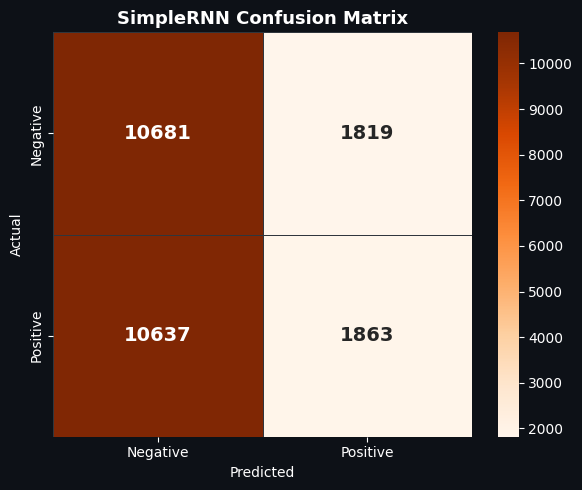

              precision    recall  f1-score   support

    Negative       0.50      0.85      0.63     12500
    Positive       0.51      0.15      0.23     12500

    accuracy                           0.50     25000
   macro avg       0.50      0.50      0.43     25000
weighted avg       0.50      0.50      0.43     25000



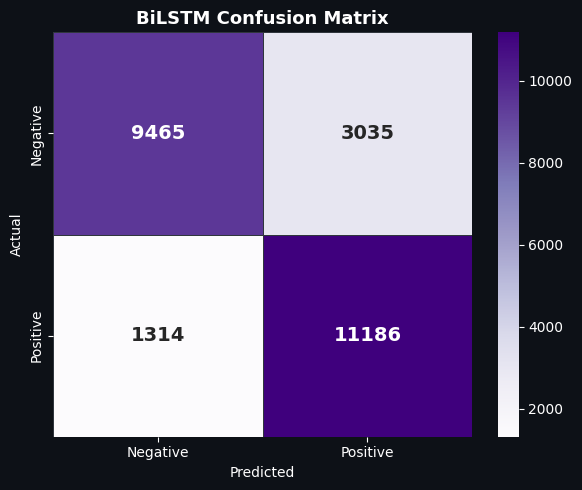

              precision    recall  f1-score   support

    Negative       0.88      0.76      0.81     12500
    Positive       0.79      0.89      0.84     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



In [15]:
def plot_confusion(model, X_pad, y_true, title, cmap="Blues"):
    y_prob = model.predict(X_pad, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#161b22")

    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=["Negative","Positive"],
                yticklabels=["Negative","Positive"],
                linewidths=0.5, linecolor="#30363d",
                annot_kws={"size": 14, "weight": "bold"})
    ax.set_xlabel("Predicted", color="white")
    ax.set_ylabel("Actual",    color="white")
    ax.set_title(title,        color="white", fontsize=13, fontweight="bold")
    ax.tick_params(colors="white")
    ax.figure.axes[-1].tick_params(colors="white")   # colourbar

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ','_').lower()}.png",
                dpi=150, bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print(classification_report(y_true, y_pred,
                                target_names=["Negative","Positive"]))
    return y_prob

rnn_probs  = plot_confusion(rnn_model,  X_test_pad, y_test,
                            "SimpleRNN Confusion Matrix",  cmap="Oranges")
lstm_probs = plot_confusion(lstm_model, X_test_pad, y_test,
                            "BiLSTM Confusion Matrix",     cmap="Purples")

# **ROC & Precision-Recall Curves**

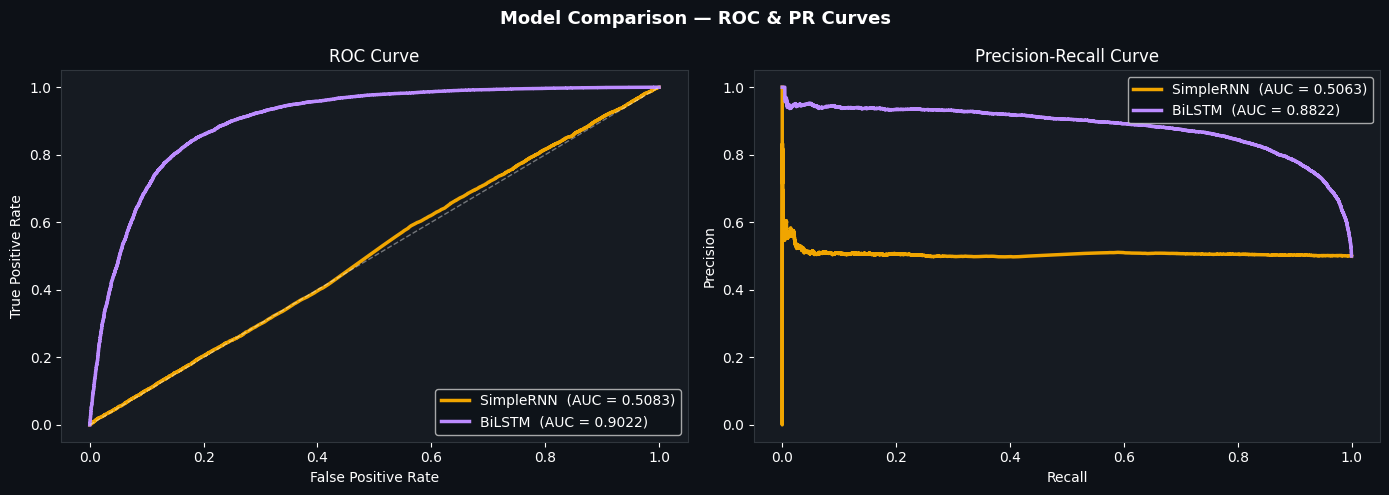

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0d1117")
for ax in axes:
    ax.set_facecolor("#161b22")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")

# ROC curves
for probs, label, color in [(rnn_probs, "SimpleRNN", "#f0a500"),
                             (lstm_probs, "BiLSTM",   "#bc8cff")]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2.5,
                 label=f"{label}  (AUC = {roc_auc:.4f})")
axes[0].plot([0,1],[0,1], "w--", lw=1, alpha=0.4)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(labelcolor="white", facecolor="#0d1117")

# Precision-Recall curves
for probs, label, color in [(rnn_probs, "SimpleRNN", "#f0a500"),
                             (lstm_probs, "BiLSTM",   "#bc8cff")]:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    pr_auc = auc(rec, prec)
    axes[1].plot(rec, prec, color=color, lw=2.5,
                 label=f"{label}  (AUC = {pr_auc:.4f})")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(labelcolor="white", facecolor="#0d1117")

plt.suptitle("Model Comparison — ROC & PR Curves", color="white",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

# **Side-by-Side Model Comparison Table**

In [18]:
comparison = pd.DataFrame({
    "Metric": ["Test Accuracy", "Precision", "Recall", "F1-Score",
               "Train Time (min)", "Parameters"],
    "SimpleRNN": [
        f"{rnn_acc:.4f}", f"{rnn_prec:.4f}", f"{rnn_rec:.4f}", f"{rnn_f1:.4f}",
        f"{rnn_train_time/60:.1f}",
        f"{rnn_model.count_params():,}"
    ],
    "BiLSTM": [
        f"{lstm_acc:.4f}", f"{lstm_prec:.4f}", f"{lstm_rec:.4f}", f"{lstm_f1:.4f}",
        f"{lstm_train_time/60:.1f}",
        f"{lstm_model.count_params():,}"
    ]
})
print("\n" + "=" * 55)
print("       Model Comparison Summary")
print("=" * 55)
print(comparison.to_string(index=False))
print("=" * 55)


       Model Comparison Summary
          Metric SimpleRNN    BiLSTM
   Test Accuracy    0.5018    0.8260
       Precision    0.5060    0.7866
          Recall    0.1490    0.8949
        F1-Score    0.2303    0.8372
Train Time (min)       0.5      74.2
      Parameters 2,574,465 2,998,145


# **Qualitative Testing (Tricky & Sarcastic Sentences)**

In [20]:
def predict_sentiment(text, model, word_index, max_len, vocab_size,
                      return_score=False):
    """
    Takes a raw string → returns 'Positive' or 'Negative'
    plus a confidence percentage."""

    tokens = re.sub(r"[^a-z0-9 ]", "", text.lower()).split()
    encoded = [word_index.get(t, 2) + 3 for t in tokens]   # 2 = <UNK>
    encoded = [min(w, vocab_size - 1) for w in encoded]
    padded  = pad_sequences([encoded], maxlen=max_len,
                             padding="post", truncating="post")
    score = float(model.predict(padded, verbose=0)[0][0])
    label = "Positive 😊" if score >= 0.5 else "Negative 😞"
    if return_score:
        return label, score
    return label

# Test sentences
test_sentences = [
    # Clear positives
    ("The acting was superb and the story was deeply moving.",             "Positive"),
    ("One of the best films I have ever seen!",                           "Positive"),
    # Clear negatives
    ("This was a complete waste of two hours. Terrible script.",          "Negative"),
    ("Boring, predictable, and painfully long.",                          "Negative"),
    # Sarcastic / tricky
    ("Oh yeah, because who doesn't love sitting through 3 hours of pain.","Negative"),
    ("The movie wasn't bad, it was actually great!",                      "Positive"),
    ("Not what I expected, but in the best possible way.",                "Positive"),
    ("I can't say I disliked it. It was surprisingly decent.",            "Positive"),
    ("The only good thing about this film was the credits rolling.",      "Negative"),
    ("A masterpiece… if you enjoy watching paint dry.",                   "Negative"),
]

print("\n" + "=" * 70)
print("  Qualitative Testing — BiLSTM Model")
print("=" * 70)
correct = 0
for sentence, expected in test_sentences:
    label, score = predict_sentiment(sentence, lstm_model, word_index,
                                     MAX_LEN, VOCAB_SIZE, return_score=True)
    tag = "✅" if label.startswith(expected) else "❌"
    print(f"\n  [{tag}] Score: {score:.3f}  |  Predicted: {label}")
    print(f"       Text: \"{sentence}\"")
    print(f"       Expected: {expected}")
    correct += label.startswith(expected)

print(f"\n  Qualitative Accuracy: {correct}/{len(test_sentences)}")
print("=" * 70)


  Qualitative Testing — BiLSTM Model

  [✅] Score: 0.939  |  Predicted: Positive 😊
       Text: "The acting was superb and the story was deeply moving."
       Expected: Positive

  [✅] Score: 0.903  |  Predicted: Positive 😊
       Text: "One of the best films I have ever seen!"
       Expected: Positive

  [✅] Score: 0.166  |  Predicted: Negative 😞
       Text: "This was a complete waste of two hours. Terrible script."
       Expected: Negative

  [❌] Score: 0.528  |  Predicted: Positive 😊
       Text: "Boring, predictable, and painfully long."
       Expected: Negative

  [✅] Score: 0.387  |  Predicted: Negative 😞
       Text: "Oh yeah, because who doesn't love sitting through 3 hours of pain."
       Expected: Negative

  [✅] Score: 0.747  |  Predicted: Positive 😊
       Text: "The movie wasn't bad, it was actually great!"
       Expected: Positive

  [✅] Score: 0.806  |  Predicted: Positive 😊
       Text: "Not what I expected, but in the best possible way."
       Expected: Positi

# **Embedding Visualisation (PCA / t-SNE on top words)**

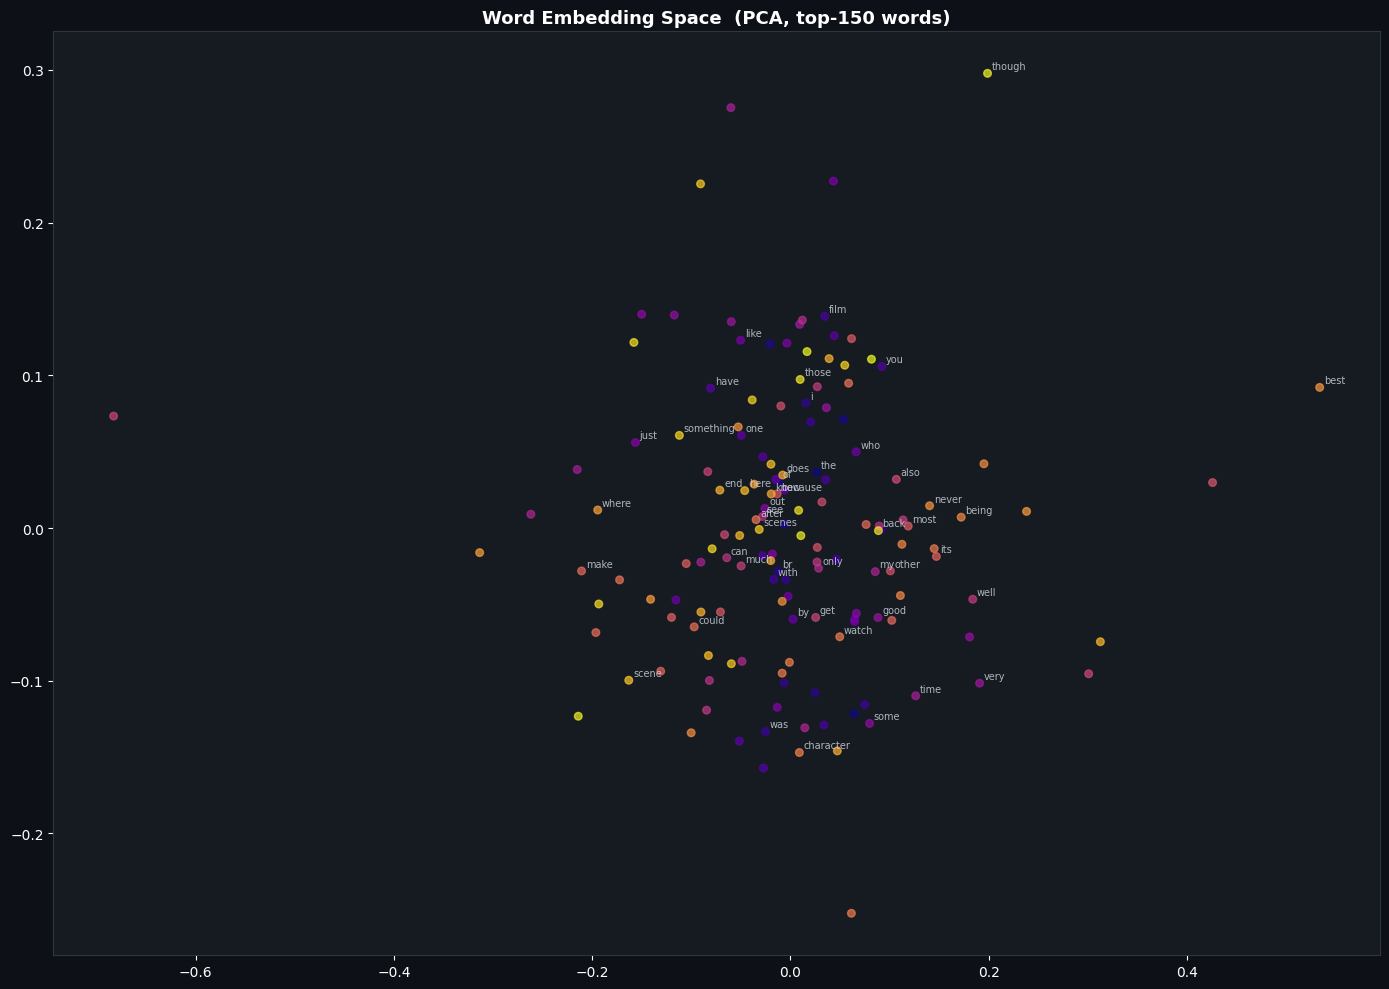

Embedding PCA plot saved


In [22]:
from sklearn.decomposition import PCA

#xxtract learned embedding weights
embedding_weights = lstm_model.get_layer("embedding").get_weights()[0]

# Pick top-N meaningful words (skip first 4 special tokens)
TOP_N    = 150
top_ids  = list(range(4, 4 + TOP_N))
top_words = [index_word.get(i, "?") for i in top_ids]
top_vecs  = embedding_weights[top_ids]

# PCA to 2D
pca   = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(top_vecs)

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#161b22")
ax.tick_params(colors="white")
ax.set_title("Word Embedding Space  (PCA, top-150 words)",
             color="white", fontsize=13, fontweight="bold")
for spine in ax.spines.values():
    spine.set_edgecolor("#30363d")

sc = ax.scatter(coords[:, 0], coords[:, 1],
                c=range(TOP_N), cmap="plasma", s=30, alpha=0.7)
for i, (x, y) in enumerate(coords):
    if i % 3 == 0:
        ax.annotate(top_words[i], (x, y), color="#c9d1d9",
                    fontsize=7, alpha=0.85,
                    xytext=(3, 3), textcoords="offset points")

plt.tight_layout()
plt.savefig("embedding_pca.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("Embedding PCA plot saved")

# **Save Final Model & Confirm Files**

In [24]:
lstm_model.save(MODEL_SAVE_PATH)
print(f"Model saved  → {MODEL_SAVE_PATH}")

import os
for fname in [MODEL_SAVE_PATH, META_SAVE_PATH,
              "eda_overview.png", "bilstm_training_history_history.png",
              "bilstm_confusion_matrix.png", "roc_pr_curves.png",
              "embedding_pca.png"]:
    size = os.path.getsize(fname) / 1024 if os.path.exists(fname) else 0
    tick = "✅" if os.path.exists(fname) else "❌"
    print(f"  {tick}  {fname:<45} {size:.1f} KB")

Model saved  → neural_sense_model.h5
  ✅  neural_sense_model.h5                         35212.5 KB
  ✅  neural_sense_meta.npz                         0.5 KB
  ✅  eda_overview.png                              101.7 KB
  ✅  bilstm_training_history_history.png           147.2 KB
  ✅  bilstm_confusion_matrix.png                   40.8 KB
  ✅  roc_pr_curves.png                             118.4 KB
  ✅  embedding_pca.png                             143.2 KB
